In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate

In [ ]:
class layer:
    def __init__(self, f, eps, mu, theta, polarization,l=0, l_in_parts_of_wavelength=False):
        self.eps = eps
        self.mu = mu
        self.l = l
        self.polarization = polarization
        self.theta = theta
        self.f = f
        self.w = 2 * np.pi * f
        mu0 = 4e-7 * np.pi
        eps0 = 8.854e-12
        eta_0 = np.sqrt(mu0/eps0)
        self.n = np.sqrt(mu * eps)
        if polarization == 'vert':
            self.z = eta_0/self.eps * np.sqrt(self.n**2 - (np.sin(theta)**2))
        elif polarization == 'horiz':
            self.z = eta_0 * self.mu/np.sqrt(self.n**2 - (np.sin(theta)**2))
        self.beta = self.w/0.3 * np.sqrt(self.n**2 - (np.sin(theta)**2))
        if l_in_parts_of_wavelength:
            self.l = l * 2*np.pi/self.beta
        self.phi = self.beta * self.l
    def abcd(self):
        return np.array([[np.cos(self.phi), -1j*self.z*np.sin(self.phi)],
                        [-1j*(1/self.z)*np.sin(self.phi), np.cos(self.phi)]], dtype=complex)

```e_on_direction(N, eps, mu, l, f=5, phi=0, theta=0)``` возвращает амплитуду поля в заданном направлении, для структуры, заданной массивами ```eps, mu, l``` (слои нумируются от экрана с нуля)
```l_for_article_resonance_structure(N, eps, mu, f=5, theta = 0)``` возвращает толщины слоёв материалов, соответствующих $\frac{\lambda}{2}$ для нулевого слоя, $\frac{\lambda}{4} $ для остальных слоёв для волн, индуцированных в соответствующих материалах волной, пришедшей под углом $\theta$

In [ ]:
eta_0 = 120 * np.pi  # Free space impedance


def v_in(theta, phi, polarization):
    if polarization == 'vert':
        return np.cos(theta )*np.cos(phi)
    elif polarization == 'horiz':
        return np.sin(phi)
    

z0 = lambda theta: eta_0*np.cos(theta)


def e_on_direction(N, eps, mu, l, f=5, phi=0, theta=0): 
    E_res = 0
    for polarization in ['vert', 'horiz']:
        abcd_all = []
        for i in range(N):
            layer_i = layer(f, eps[i], mu[i], theta, polarization, l=l[i])
            abcd_all.append(layer_i.abcd())   
        v_in_i = v_in(theta, phi, polarization)
        z0_i = z0(theta)
        abcd_total = np.eye(2, dtype=complex)
        for abcd in abcd_all:
            abcd_total = np.matmul(abcd_total, abcd)
        A, B, C, D = abcd_total.flatten()
        I_0 = (-C*B/A+D)*2*v_in_i/(z0_i-B/A)
        shift_layer = layer(f, eps[0], mu[0], theta, polarization, l=l[0]/2)
        abcd_shift = np.linalg.inv(shift_layer.abcd())
        A_s, B_s, C_s, D_s = abcd_shift.flatten()
        E_res += B_s*I_0
    return E_res


def l_for_article_resonance_structure(N, eps, mu, f=5, theta = 0):
    l = np.zeros(N)
    for i in range(N):
        layer_i = layer(f, eps[i], mu[i], theta, 'vert', l=0.25, l_in_parts_of_wavelength=True)
        l[i] = layer_i.l
    l[0] *= 2
    return l

for N= 2 суммарная длина 19.743416490252567 mm
for N= 4 суммарная длина 31.986832980505135 mm
for N= 6 суммарная длина 44.230249470757705 mm


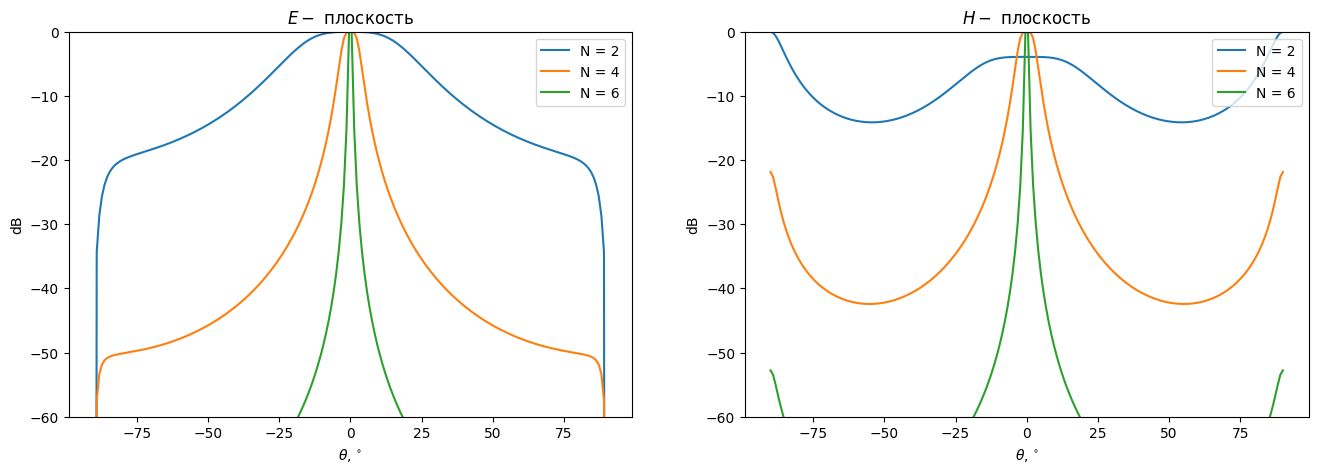

In [ ]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(16, 5)
for N in [2, 4, 6]:
    eps = np.ones(N)
    mu = np.ones(N)
    eps[1::2] = 10
    mu[::2] = 4
    l = l_for_article_resonance_structure(N, eps, mu, f=5, theta = 0)
    theta = np.linspace(-np.pi/2, np.pi/2, 200)
    P_e_plane = np.zeros(200)
    P_h_plane = np.zeros(200)
    for i in range(len(theta)):
        P_e_plane[i] = np.abs(e_on_direction(N, eps, mu, l, theta = theta[i], phi=0))**2
        P_h_plane[i] = np.abs(e_on_direction(N, eps, mu, l, theta = theta[i], phi=-np.pi/2))**2
    ax[0].plot(theta*180/np.pi, 10*np.log10(P_e_plane/np.max(P_e_plane)), label=f'N = {N}')
    ax[1].plot(theta*180/np.pi, 10*np.log10(P_h_plane/np.max(P_h_plane)), label=f'N = {N}')
    print('for N=', N, 'суммарная длина', sum(l)*1000, 'mm')
ax[0].set_ylim(-60, 0)
ax[1].set_ylim(-60, 0)
ax[0].set_title(r'$E - $ плоскость')
ax[1].set_title(r'$H - $ плоскость')
ax[0].set_ylabel('dB')
ax[1].set_ylabel('dB')
ax[0].set_xlabel(r'$\theta$, $^{\circ}$')
ax[1].set_xlabel(r'$\theta$, $^{\circ}$')
ax[0].legend()
ax[1].legend(loc = 'upper right')
plt.show()

из прикольного можно пускать лучи под произвольным углом

for N= 2 суммарная длина 20.29577799898228 mm
for N= 4 суммарная длина 32.84558930554972 mm
for N= 6 суммарная длина 45.39540061211717 mm


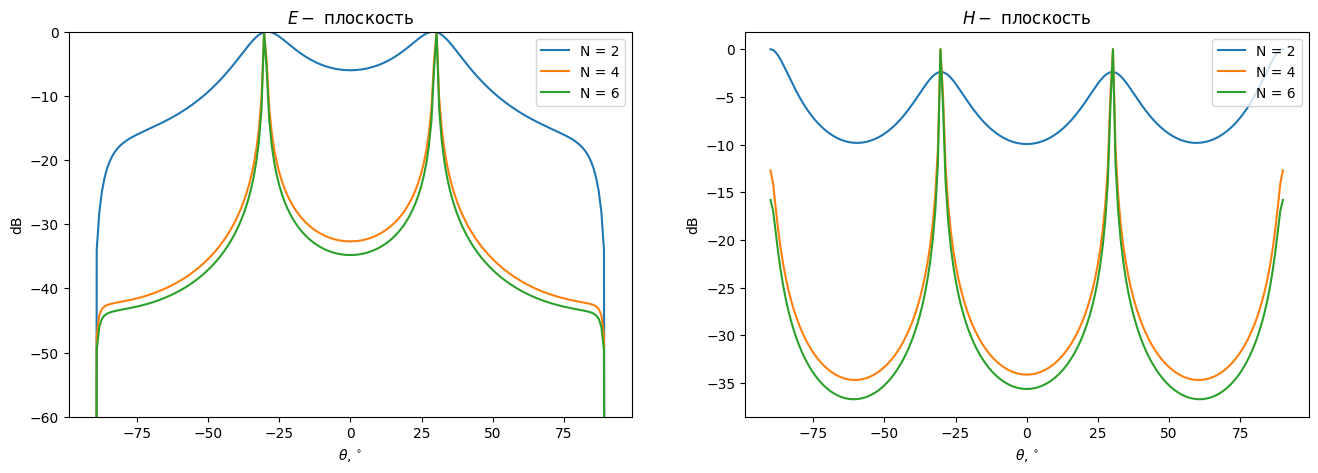

In [ ]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(16, 5)
for N in [2, 4, 6]:
    eps = np.ones(N)
    mu = np.ones(N)
    eps[1::2] = 10
    mu[::2] = 4
    l = l_for_article_resonance_structure(N, eps, mu, f=5, theta = np.pi/6)
    theta = np.linspace(-np.pi/2, np.pi/2, 200)
    P_e_plane = np.zeros(200)
    P_h_plane = np.zeros(200)
    for i in range(len(theta)):
        P_e_plane[i] = np.abs(e_on_direction(N, eps, mu, l, theta = theta[i], phi=0))**2
        P_h_plane[i] = np.abs(e_on_direction(N, eps, mu, l, theta = theta[i], phi=np.pi/2))**2
    ax[0].plot(theta*180/np.pi, 10*np.log10(P_e_plane/np.max(P_e_plane)), label=f'N = {N}')
    ax[1].plot(theta*180/np.pi, 10*np.log10(P_h_plane/np.max(P_h_plane)), label=f'N = {N}')
    print('for N=', N, 'суммарная длина', sum(l)*1000, 'mm')
ax[0].set_ylim(-60, 0)
ax[0].set_title(r'$E - $ плоскость')
ax[1].set_title(r'$H - $ плоскость')
ax[0].set_ylabel('dB')
ax[1].set_ylabel('dB')
ax[0].set_xlabel(r'$\theta$, $^{\circ}$')
ax[1].set_xlabel(r'$\theta$, $^{\circ}$')
ax[0].legend()
ax[1].legend(loc = 'upper right')
plt.show()